# Medical Insurance Price prediction

In [1]:
# Import modules
import numpy as np
import pandas as pd
import copy

## ID3 Decision Tree

In [2]:
# Helper functions
def cov(values: pd.Series):
  """
  Compute the coefficient of variation (CoV) for a numeric pandas Series.

  The coefficient of variation is defined as the ratio of the standard
  deviation to the mean:

      CoV = std(values) / mean(values)

  Parameters
  ----------
  values : pd.Series
      A pandas Series containing numeric values.

  Returns
  -------
  float
      The coefficient of variation of the input values.
  """


  return np.std(values) / np.abs(np.mean(values))

def stdr_xy(X: pd.Series, y: pd.Series):
  """
  Compute the standard deviation reduction (STDR) of target variable y
  after splitting by the categorical values in X.

  The function calculates:
      STDR = std(y) - sum_over_groups( (n_i / n) * std(y_i) )

  where:
      - y_i is the subset of y corresponding to each unique value in X
      - n_i is the size of each subset
      - n is the total number of samples

  Parameters
  ----------
  X : pd.Series
      A pandas Series containing categorical or discrete grouping values.
  y : pd.Series
      A pandas Series containing numeric target values aligned with X.

  Returns
  -------
  float
      The reduction in standard deviation of y after partitioning by X.
  """

  stdr = 0
  for val in X.unique():

    x_value = X[X == val]
    y_value = y.loc[x_value.index]

    stdr += (len(x_value) / len(X)) * np.std(y_value)

  stdr = np.std(y) - stdr

  return stdr


def encode_columns(columns: list):

  encoding = {}

  for i in range(len(columns)):

    encoding[i] = columns[i]

  return encoding



In [3]:
class DecisionNode():
  """
  A node in a decision tree structure.

  A DecisionNode can represent either:
  - An internal decision node that splits on a feature and contains branches, or
  - A leaf node that stores a predicted value.

  Parameters
  ----------
  feature_idx : int, optional
      The index of the feature used for splitting at this node.
      Should be None for leaf nodes.
  branches : dict, optional
      A dictionary mapping feature values to child DecisionNode objects.
      Used only for internal (non-leaf) nodes.
  leaf_value : float, optional
      The prediction value stored in the node if it is a leaf.
      Should be None for internal nodes.

  Attributes
  ----------
  feature_idx : int
      Feature index used for splitting at this node.
  branches : dict
      Mapping of feature values to child nodes.
  leaf_value : float
      Prediction value if the node is a leaf.
  """

  def __init__(self, feature_idx: int = None, branches: dict =None, leaf_value: float =None):

    self.feature_idx = feature_idx
    self.branches = branches
    self.leaf_value = leaf_value

In [4]:
class DecisionTree():
  """
  A simple Decision Tree implementation for regression tasks.

  The tree splits data based on the feature that maximizes a custom
  standard deviation reduction metric (stdr_xy). Splitting stops when:
  - The number of samples is less than or equal to min_samples
  - The maximum depth is reached
  - The covariance of the target values is below the splitting threshold

  Parameters
  ----------
  splitting_threshold : float
      Minimum covariance threshold required to continue splitting.
  max_depth : int
      Maximum depth allowed for the tree.
  min_samples : int
      Minimum number of samples required to split a node.
  """

  def __init__(self, max_depth: int, min_samples: int, splitting_threshold: float = None):
    """
    Initialize the Decision Tree with stopping criteria.

    Parameters
    ----------
    splitting_threshold : float
        Minimum covariance required to continue splitting.
    max_depth : int
        Maximum depth of the tree.
    min_samples : int
        Minimum number of samples required to split.
    """

    # Threshold for covariance stopping condition
    self.splitting_threshold = splitting_threshold

    # Maximum allowed depth of the tree
    self.max_depth = max_depth

    # Minimum number of samples required to perform a split
    self.min_samples = min_samples

    # Root node of the tree (DecisionNode)
    self.root: DecisionNode = None

    # Dictionary for encoding column names to numeric feature indices
    self.column_encoding = None

    # Dictionary storing unique values per column
    self.columns_values = None


  def build(self, X_train: pd.DataFrame, y_train: pd.Series, depth: int = 0):
    """
    Recursively builds the decision tree.

    Parameters
    ----------
    X_train : pd.DataFrame
        Feature dataset.
    y_train : pd.Series
        Target values.

    Returns
    -------
    DecisionNode
        A node representing either a leaf or an internal split node.
    """

    # Stopping conditions:
    # 1. Too few samples
    # 2. Maximum depth reached
    # 3. Target covariance is below threshold
    if len(X_train) <= self.min_samples or depth >= self.max_depth or \
       (self.splitting_threshold and cov(y_train) <= self.splitting_threshold):
      # Create a leaf node with the mean target value
      return DecisionNode(leaf_value=np.mean(y_train))

    # Track the best standard deviation reduction
    max_stdr = None

    # Feature chosen for splitting
    split_feature = None

    # Iterate over all features to find the best split
    for col in X_train.columns:
      # Compute custom standard deviation reduction metric
      stdr = stdr_xy(X_train[col], y_train)

      # Update best feature if improvement found
      if max_stdr is None or stdr > max_stdr:
        max_stdr = stdr
        split_feature = col

    # Dictionary to store child branches for this node
    branches = {}

    # Create a branch for each unique value of the selected feature
    for col_value in self.columns_values[split_feature]:
      # If this value does not exist in current data, make leaf with mean
      if col_value not in X_train[split_feature].values:
        branches[col_value] = DecisionNode(leaf_value=np.mean(y_train))
      else:
        # Subset of X where feature equals the specific value
        X_col_value = X_train[X_train[split_feature] == col_value]

        # Safety check: if no rows match, create leaf
        if len(X_col_value) == 0:
          branches[col_value] = DecisionNode(leaf_value=np.mean(y_train))
        else:
          # Corresponding target values
          y_col_value = y_train.loc[X_col_value.index]

          # Remove the splitting feature from the subset for next split
          X_col_value = X_col_value.drop(split_feature, axis=1)

          # Recursively build subtree for this branch
          branches[col_value] = self.build(X_col_value, y_col_value, depth + 1)

    # Return internal decision node
    return DecisionNode(feature_idx=split_feature, branches=branches)


  def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
    """
    Train the Decision Tree on the provided dataset.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training target values.
    """

    # Dictionary to store unique values per column
    self.columns_values = {}

    # Encode column names to numeric feature indices
    self.column_encoding = encode_columns(X_train.columns)

    # Reverse encoding: numeric index -> column name
    reverse_column_encoding = {val: key for key, val in self.column_encoding.items()}

    # Rename columns using numeric encoding
    X_train = X_train.rename(columns=reverse_column_encoding)
    X_train.columns = X_train.columns.astype(int)

    # Store unique values for each feature
    for col in X_train.columns:
      self.columns_values[col] = X_train[col].unique()

    # Build the tree starting from the root
    self.root = self.build(X_train, y_train)


  def __visualize_node(self, node: DecisionNode, depth=0):
    """
    Recursively prints a visual representation of the tree.

    Parameters
    ----------
    node : DecisionNode
        Current node being visualized.
    depth : int
        Current depth (used for indentation).
    """

    # If this is a leaf node, print its value
    if node.leaf_value is not None:
      print(node.leaf_value)
      return

    # Print feature used for splitting
    print("[ %s ]" % self.column_encoding[node.feature_idx])

    # Recursively print branches
    for feature_value, node in node.branches.items():
      # Indentation based on depth level
      print("  " * depth + f" -- {feature_value} --> ", end="")
      self.__visualize_node(node, depth=depth + 1)


  def visualize(self):
    """
    Public method to print the full tree structure.
    """
    self.__visualize_node(self.root)


  def __traverse(self, node: DecisionNode, X: dict):
    """
    Recursively traverse the tree to make a prediction.

    Parameters
    ----------
    node : DecisionNode
        Current node in traversal.
    X : dict
        Single sample represented as a dictionary of feature-value pairs.

    Returns
    -------
    float
        Predicted value from the leaf node.
    """

    # If leaf node, return stored prediction
    if node.leaf_value is not None:
      return node.leaf_value

    # Get the feature value for current split
    feature_value = X[node.feature_idx]

    # Move to the corresponding child node
    next_node = node.branches.get(feature_value)

    # Continue traversal
    return self.__traverse(next_node, X)


  def predict(self, X: dict):
    """
    Predict the output for a single sample.

    Parameters
    ----------
    X : dict
        Feature dictionary for one data sample.

    Returns
    -------
    float
        Predicted value.
    """

    # Encode the column names of input data to feature indices
    X_inp = copy.deepcopy(X)
    for key, value in self.column_encoding.items():
      X_inp[key] = X_inp.pop(value)

    # Return the predicted value
    return self.__traverse(self.root, X_inp)

### Fit a dummy dataset on the decision tree

In [5]:
# Dummy data
data = {
    "Outlook": ["Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Sunny", "Overcast", "Rainy", "Rainy", "Sunny", "Rainy", "Overcast", "Overcast", "Sunny"],
    "Temp": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool", "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal", "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Windy": ["False", "True", "False", "False", "False", "True", "True", "False", "False", "False", "True", "True", "False", "True"],
    "Windy": ["False", "True", "False", "False", "False", "True", "True", "False", "False", "False", "True", "True", "False", "True"],
    "HoursPlayed": [25,30,46,45,52,23,43,35,38,46,48,52,44,30],
}

df = pd.DataFrame(data)

# Fit the decision tree on the dummy data
tree = DecisionTree(max_depth=4, min_samples=3, splitting_threshold=0.1)
tree.fit(df.drop("HoursPlayed", axis=1), df["HoursPlayed"])

# Visualize the decision tree
tree.visualize()

[ Outlook ]
 -- Rainy --> [ Temp ]
   -- Hot --> 27.5
   -- Mild --> 41.5
   -- Cool --> 38.0
 -- Overcast --> 46.25
 -- Sunny --> [ Windy ]
   -- False --> 47.666666666666664
   -- True --> 26.5


In [6]:
# Function to evaluate the model
def evaluate(model, X_test: pd.DataFrame, y_test: pd.Series):
  """
  Evaluate a regression model using MAE, MSE, and R² score.

  Parameters
  ----------
  model : object
      Trained regression model with a .predict() method.
  X_test : pd.DataFrame
      Test feature set.
  y_test : pd.Series
      True target values for the test set.

  Returns
  -------
  dict
      Dictionary containing "mae", "mse", and "r2_score".
  """

  # Generate predictions for each row in X_test
  # model.predict expects a dictionary of feature-value pairs
  y_test_pred = pd.Series(
    [model.predict(item.to_dict()) for _, item in X_test.iterrows()],
    index=X_test.index
  )

  # Mean Absolute Error
  mae = np.mean(np.abs(y_test - y_test_pred))

  # Mean Squared Error
  mse = np.mean(np.square(y_test - y_test_pred))

  # R² score (coefficient of determination)
  r2_score = 1 - (np.sum(np.square(y_test - y_test_pred)) /
                  np.sum(np.square(y_test - np.mean(y_test))))

  # Return evaluation metrics
  return {
    "mae": mae,
    "mse": mse,
    "r2_score": r2_score,
  }

## Gradient Boosting

The differentiable loss function used is `1 / 2 (observed - predicted)^2`.
Therefore all the prediction functions are made to accomodate the given loss function for easier calculations.

In [7]:
class GradientBoosting:
  """
  Gradient Boosting Regressor using Decision Trees as base learners.

  Parameters
  ----------
  learners_count : int
      Number of base learners (trees) to train sequentially.
  learning_rate : float
      Scaling factor applied to each tree's predictions.
  max_depth : int
      Maximum depth allowed for each decision tree.
  min_samples : int
      Minimum samples required to split a node in each tree.
  splitting_threshold : float, optional
      Minimum covariance required to continue splitting a node.
  """

  def __init__(self, learners_count: int, learning_rate: float, max_depth: int,
               min_samples: int, splitting_threshold: float = None):
    self.learners_count = learners_count
    self.learning_rate = learning_rate
    self.splitting_threshold = splitting_threshold
    self.max_depth = max_depth
    self.min_samples = min_samples

    # List of trained DecisionTree learners
    self.learners = None

    # Initial prediction (mean of target values)
    self.f_c = None


  def fit(self, X_train: pd.DataFrame, y_train: pd.Series, validation_data: list = None):
    """
    Train the Gradient Boosting model.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training target values.
    validation_data : list, optional
        Optional validation data [X_val, y_val] for evaluation during training.
    """

    # Initial prediction is the mean of y_train
    self.f_c = np.mean(y_train)

    # Current ensemble prediction
    f_x = pd.Series([self.f_c] * len(y_train), index=y_train.index)

    # Train sequentially for the number of learners specified
    for i in range(self.learners_count):

      print("Training Learner: ", i + 1)

      # Compute residuals (negative gradients)
      residual = y_train - f_x

      # Train a decision tree on residuals
      d_t = DecisionTree(
        splitting_threshold=self.splitting_threshold,
        max_depth=self.max_depth,
        min_samples=self.min_samples
      )
      d_t.fit(X_train, residual)

      # Add tree to learners list
      if self.learners:
        self.learners.append(d_t)
      else:
        self.learners = [d_t]

      # Update ensemble prediction
      f_x += self.learning_rate * pd.Series(
        [d_t.predict(row.to_dict()) for _, row in X_train.iterrows()],
        index=y_train.index
      )

      # Optional evaluation on validation set
      if validation_data is not None:
        X_val, y_val = validation_data
        print(evaluate(self, X_val, y_val))


  def predict(self, X: dict):
    """
    Predict the target value for a single sample.

    Parameters
    ----------
    X : dict
        Feature dictionary for one data sample.

    Returns
    -------
    float
        Predicted value.
    """

    # Start with initial prediction and add contributions from each learner
    y_pred = self.f_c + sum(
      (self.learning_rate * learner.predict(X)) for learner in self.learners
    )

    return y_pred

### Fit a dummy dataset on Gradient Boosting model


In [8]:
# Dummy dataset
df


,Outlook,Temp,Humidity,Windy,HoursPlayed
0,Rainy,Hot,High,False,25
1,Rainy,Hot,High,True,30
2,Overcast,Hot,High,False,46
3,Sunny,Mild,High,False,45
4,Sunny,Cool,Normal,False,52
5,Sunny,Cool,Normal,True,23
6,Overcast,Cool,Normal,True,43
7,Rainy,Mild,High,False,35
8,Rainy,Cool,Normal,False,38
9,Sunny,Mild,Normal,False,46


In [9]:
# Split the dataset into features and target
X = df.drop("HoursPlayed", axis=1)
y = df["HoursPlayed"]

In [10]:
# Configure the gradient boosting model
gb = GradientBoosting(learners_count=2, learning_rate=0.1, max_depth=4, min_samples=2, splitting_threshold = 0.1)

# Fit the dummy data on Gradient Boosting model
gb.fit(X, y)

evaluate(gb, X, y)

Training Learner:  1
Training Learner:  2


{'mae': np.float64(6.854795918367345),
 'mse': np.float64(60.049680102040796),
 'r2_score': np.float64(0.3088415467731519)}

### Visualize the learner trees from GB

In [11]:
for tree in gb.learners:

  tree.visualize()

[ Outlook ]
 -- Rainy --> [ Temp ]
   -- Hot --> -12.285714285714285
   -- Mild --> 1.7142857142857153
   -- Cool --> -1.7857142857142847
 -- Overcast --> [ Temp ]
   -- Hot --> 5.214285714285715
   -- Mild --> 12.214285714285715
   -- Cool --> 3.2142857142857153
 -- Sunny --> [ Windy ]
   -- False --> [ Temp ]
     -- Hot --> 7.880952380952382
     -- Mild --> 5.714285714285715
     -- Cool --> 12.214285714285715
   -- True --> -13.285714285714285
[ Outlook ]
 -- Rainy --> [ Temp ]
   -- Hot --> -11.057142857142857
   -- Mild --> 1.5428571428571445
   -- Cool --> -1.607142857142854
 -- Overcast --> [ Temp ]
   -- Hot --> 4.692857142857143
   -- Mild --> 10.992857142857147
   -- Cool --> 2.892857142857146
 -- Sunny --> [ Windy ]
   -- False --> [ Temp ]
     -- Hot --> 7.092857142857146
     -- Mild --> 5.142857142857146
     -- Cool --> 10.992857142857147
   -- True --> -11.957142857142856


### Predict and compare the predicted and actual result from the model

In [12]:
y_pred = pd.Series([gb.predict(item.to_dict()) for _, item in X.iterrows()], name="Prediction")
pd.concat([y, y_pred], axis=1)

,HoursPlayed,Prediction
0,25,37.451429
1,30,37.451429
2,46,40.776429
3,45,40.871429
4,52,42.106429
5,23,37.261429
6,43,40.396429
7,35,40.111429
8,38,39.446429
9,46,40.871429


## Working on real data
Loading medical insurance dataset from Kaggle <br>
[Source](https://www.kaggle.com/datasets/sridharstreaks/insurance-data-for-machine-learning/data)

In [13]:
import kagglehub
import os

dataset_dirt = kagglehub.dataset_download("sridharstreaks/insurance-data-for-machine-learning")
dataset_dirt

100%|██████████| 21.3M/21.3M [00:00<00:00, 71.0MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/sridharstreaks/insurance-data-for-machine-learning/versions/1'

In [14]:
# Load the saved dataset
df = pd.read_csv(dataset_dirt + "/" + os.listdir(dataset_dirt)[0])
df

,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges
0,46,male,21.45,5,yes,southeast,Diabetes,NaN,Never,Blue collar,Premium,20460.307669
1,25,female,25.38,2,yes,northwest,Diabetes,High blood pressure,Occasionally,White collar,Premium,20390.899218
2,38,male,44.88,2,yes,southwest,NaN,High blood pressure,Occasionally,Blue collar,Premium,20204.476302
3,25,male,19.89,0,no,northwest,NaN,Diabetes,Rarely,White collar,Standard,11789.029843
4,49,male,38.21,3,yes,northwest,Diabetes,High blood pressure,Rarely,White collar,Standard,19268.309838
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,59,male,46.67,2,no,northeast,High blood pressure,NaN,Frequently,Student,Basic,11584.134900
999996,33,male,36.83,2,no,northeast,NaN,High blood pressure,Frequently,Unemployed,Basic,9834.871456
999997,39,male,39.84,0,yes,northeast,Heart disease,High blood pressure,Rarely,Blue collar,Standard,22076.632856
999998,37,female,45.06,4,yes,northeast,High blood pressure,Diabetes,Occasionally,Unemployed,Premium,20297.618728


#### Understanding data

In [15]:
# Track the columns' types
numeric_columns = ["age", "bmi", "children"]
categorical_columns = ["gender", "smoker", "region", "medical_history", "family_medical_history", "exercise_frequency", "occupation", "coverage_level"]

In [16]:
# Get the descriptive statistics and summary of the data
df.describe(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     1000000 non-null  int64  
 1   gender                  1000000 non-null  object 
 2   bmi                     1000000 non-null  float64
 3   children                1000000 non-null  int64  
 4   smoker                  1000000 non-null  object 
 5   region                  1000000 non-null  object 
 6   medical_history         749238 non-null   object 
 7   family_medical_history  749596 non-null   object 
 8   exercise_frequency      1000000 non-null  object 
 9   occupation              1000000 non-null  object 
 10  coverage_level          1000000 non-null  object 
 11  charges                 1000000 non-null  float64
dtypes: float64(2), int64(2), object(8)
memory usage: 91.6+ MB


(                  age             bmi        children         charges
 count  1000000.000000  1000000.000000  1000000.000000  1000000.000000
 mean        41.495282       34.001839        2.499886    16735.117481
 std         13.855189        9.231680        1.707679     4415.808211
 min         18.000000       18.000000        0.000000     3445.011643
 25%         29.000000       26.020000        1.000000    13600.372379
 50%         41.000000       34.000000        2.000000    16622.127973
 75%         53.000000       41.990000        4.000000    19781.465410
 max         65.000000       50.000000        5.000000    32561.560374,
 None)

In [17]:
# Check for missing values in each column
df.isna().any(), df.isnull().any()

(age                       False
 gender                    False
 bmi                       False
 children                  False
 smoker                    False
 region                    False
 medical_history            True
 family_medical_history     True
 exercise_frequency        False
 occupation                False
 coverage_level            False
 charges                   False
 dtype: bool,
 age                       False
 gender                    False
 bmi                       False
 children                  False
 smoker                    False
 region                    False
 medical_history            True
 family_medical_history     True
 exercise_frequency        False
 occupation                False
 coverage_level            False
 charges                   False
 dtype: bool)

#### Visualization

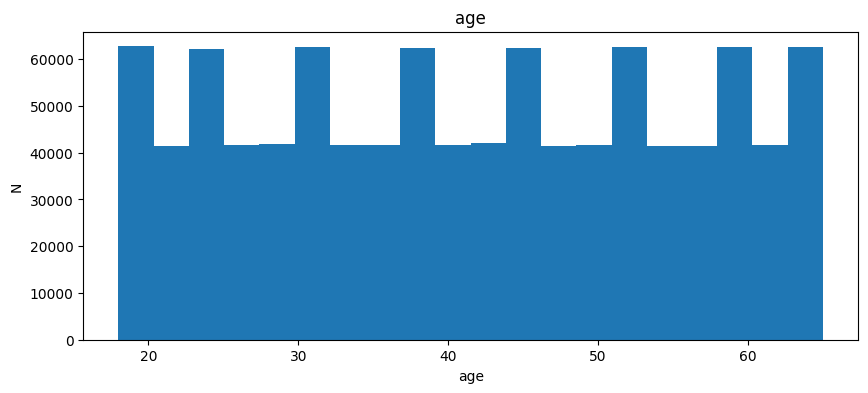

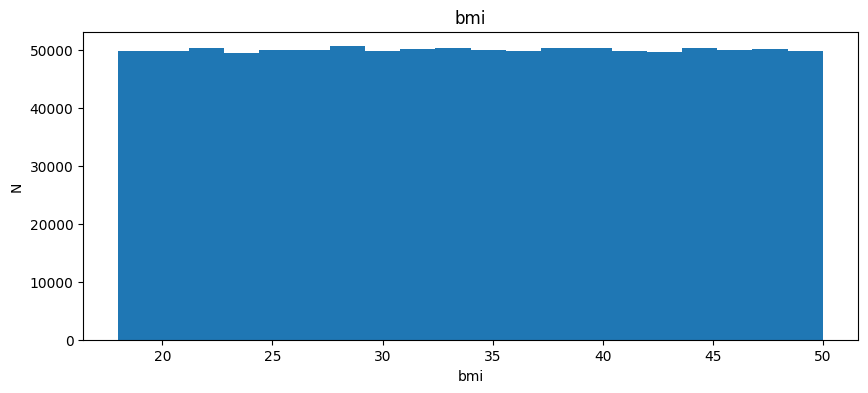

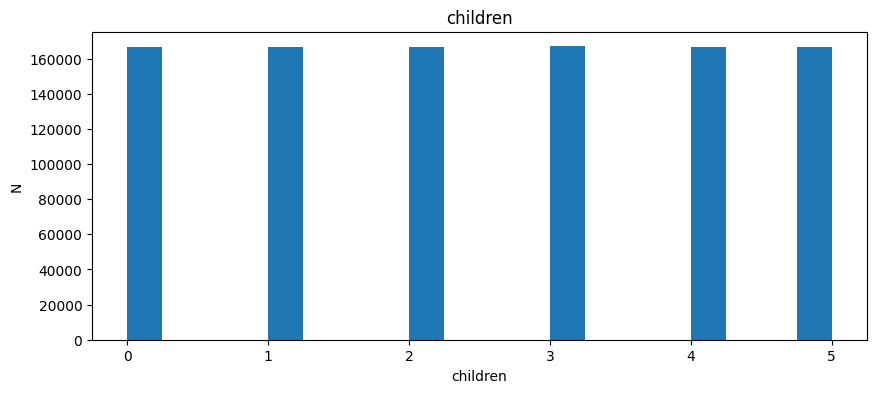

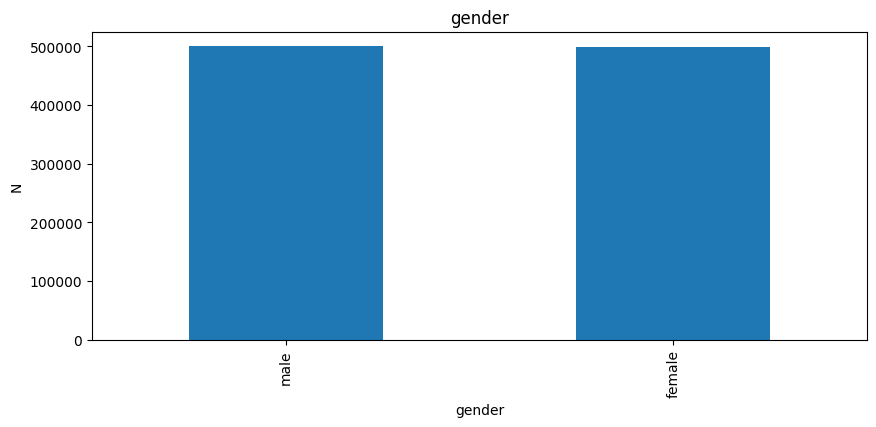

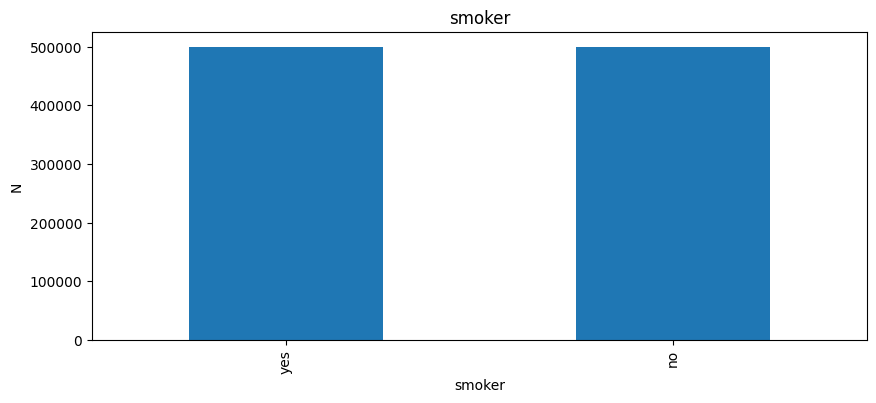

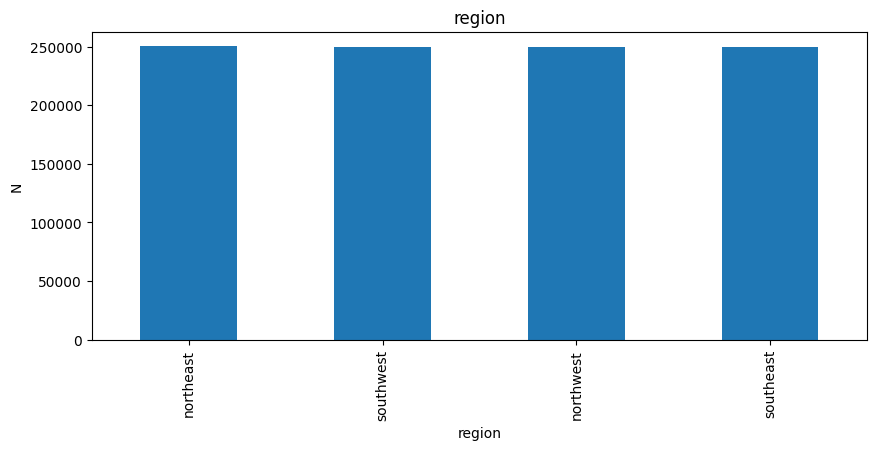

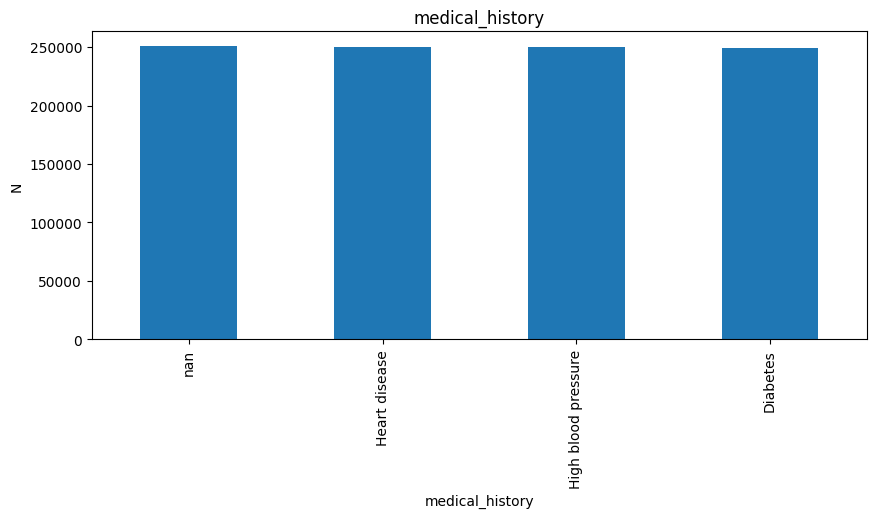

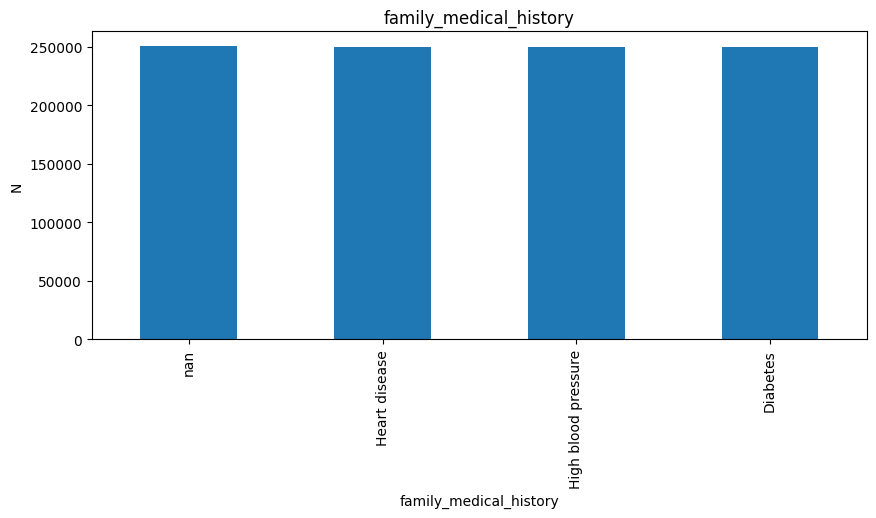

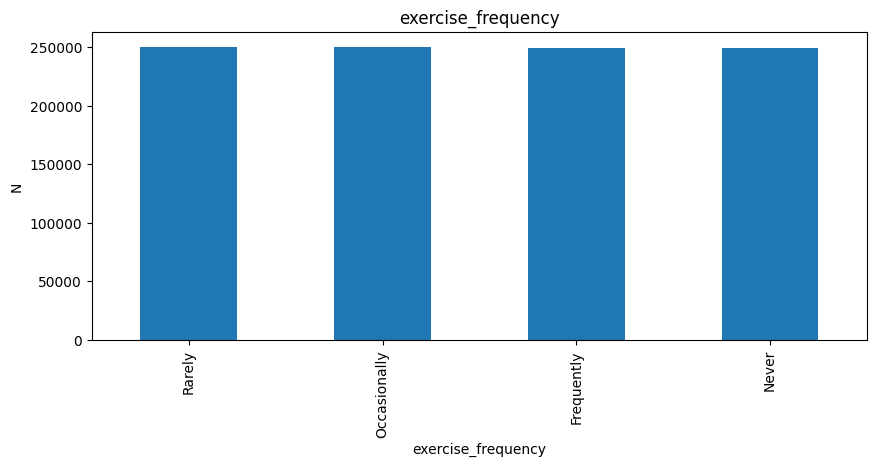

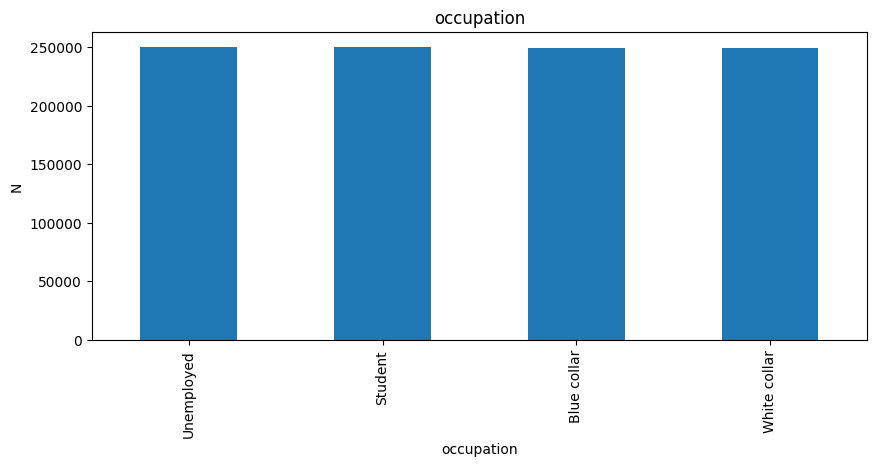

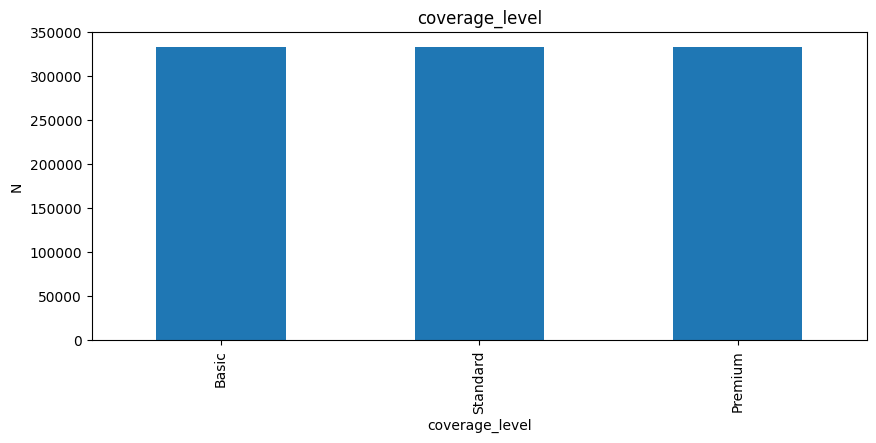

In [18]:
import matplotlib.pyplot as plt

# Plot numeric histograms
for col in numeric_columns:
  plt.figure(figsize=(10, 4))
  plt.hist(df[col], bins=20)
  plt.xlabel(col)
  plt.ylabel("N")
  plt.title(col)
  plt.show()

# Plot categorical bar charts
for col in categorical_columns:
  plt.figure(figsize=(10, 4))
  df[col].value_counts(dropna=False).plot(kind='bar')
  plt.xlabel(col)
  plt.ylabel("N")
  plt.title(col)
  plt.show()

#### Preprocessing

In [19]:
# Fill NaNs with "no" for relevant medical history columns

df["medical_history"] = df["medical_history"].fillna("no")
df["family_medical_history"] = df["family_medical_history"].fillna("no")

In [20]:
# Split the dataset into features and target

X = df.drop("charges", axis=1)
y = df["charges"]
X, y

(        age  gender    bmi  children smoker     region      medical_history  \
 0        46    male  21.45         5    yes  southeast             Diabetes   
 1        25  female  25.38         2    yes  northwest             Diabetes   
 2        38    male  44.88         2    yes  southwest                   no   
 3        25    male  19.89         0     no  northwest                   no   
 4        49    male  38.21         3    yes  northwest             Diabetes   
 ...     ...     ...    ...       ...    ...        ...                  ...   
 999995   59    male  46.67         2     no  northeast  High blood pressure   
 999996   33    male  36.83         2     no  northeast                   no   
 999997   39    male  39.84         0    yes  northeast        Heart disease   
 999998   37  female  45.06         4    yes  northeast  High blood pressure   
 999999   41    male  30.02         2    yes  northeast             Diabetes   
 
        family_medical_history exercis

### Features Tansformation / Encoding

In [21]:
from abc import ABC
import pandas as pd

class BaseEncoder(ABC):
  """Base encoder class for custom encoding strategies."""

  def fit_transform(self, X: pd.DataFrame, columns: list | dict):
    pass

  def transform(self, X: dict):
    pass


class CategoricalLabelEncoder(BaseEncoder):
  """Encoder for label encoding multiple categorical columns."""

  def __init__(self):
    self.encoding = None

  def fit_transform(self, X: pd.DataFrame, columns: list):
    X_ = X.copy()
    self.encoding = {}

    for column in columns:
      self.encoding[column] = {value: i for i, value in enumerate(X_[column].unique())}

    for column in columns:
      for col_value in self.encoding[column].keys():
        X_[column] = X_[column].replace(col_value, self.encoding[column][col_value])

    return X_

  def transform(self, X: dict):
    X_ = copy.deepcopy(X)

    for column, column_encoding in self.encoding.items():
      X_[column] = column_encoding[X_[column]]

    return X_


class DiscretizationEncoder(BaseEncoder):
  """Encoder for discretizing continuous features into specified intervals."""

  def __init__(self):
    self.encoding = None

  def fit_transform(self, X: pd.DataFrame, columns: dict):
    X_ = X.copy()
    self.encoding = columns

    for column, col_discrete_infos in columns.items():
      for col_discrete_info in col_discrete_infos:
        if not col_discrete_info[1]:
          X_[column] = X_[column].apply(lambda x: col_discrete_info[0] if x < col_discrete_info[2] else x)
        elif not col_discrete_info[2]:
          X_[column] = X_[column].apply(lambda x: col_discrete_info[0] if x >= col_discrete_info[1] else x)
        else:
          X_[column] = X_[column].apply(lambda x: col_discrete_info[0] if (x >= col_discrete_info[1]) and (x < col_discrete_info[2]) else x)

    return X_

  def transform(self, X: dict):
    X_ = copy.deepcopy(X)

    for column, col_discrete_infos in self.encoding.items():
      t = filter(
        lambda col_discrete_info: X_[column] < col_discrete_info[2] if not col_discrete_info[1]
        else X_[column] >= col_discrete_info[1] if not col_discrete_info[2]
        else X_[column] >= col_discrete_info[1] and X_[column] < col_discrete_info[2], col_discrete_infos)

      X_[column] = list(t)[0][0]

    return X_


class EncoderPipeline:
  """Pipeline for applying multiple encoders sequentially."""

  def __init__(self):
    self.encoders = []

  def fit_transform(self, X: pd.DataFrame, encoders: list):
    X_ = X.copy()

    for encoder in encoders:
      X_ = encoder[0].fit_transform(X_, encoder[1])
      self.encoders.append(encoder[0])

    return X_

  def transform(self, X: dict):
    X_ = copy.deepcopy(X)

    for encoder in self.encoders:
      X_ = encoder.transform(X_)

    return X_

#### Dataset discretization breakdown
#### Age Discretization:
- 18–29: Young adults (early adulthood, likely fewer medical issues)
- 30–39: Early middle age (risk of lifestyle-related issues may begin)
- 40–49: Middle age (increasing medical concerns)
- 50–59: Late middle age (higher risk of chronic conditions)
- 60+: Seniors (medical needs typically increase)

#### BMI Discretization:
- Underweight: BMI < 18.5
- Normal weight: BMI 18.5–24.9
- Overweight: BMI 25–29.9
- Obesity (Class 1): BMI 30–34.9
- Obesity (Class 2): BMI 35–39.9
- Severe Obesity (Class 3): BMI ≥ 40


In [22]:
# Label encoding for categorical features
label_encoder = CategoricalLabelEncoder()

# Data Discretization for numeric feature
discretization_encoder = DiscretizationEncoder()
discretization_columns = {
  "age": [
    (0, 18, 30),
    (1, 30, 40),
    (2, 40, 50),
    (3, 50, 60),
    (4, 60, None),
  ],
  "bmi": [
    (0, None, 18.5),
    (1, 18.5, 25),
    (2, 25, 30),
    (3, 30, 35),
    (4, 35, 40),
    (5, 40, None),
  ]
}

# Apply encoding and discretization
encoders = EncoderPipeline()
X = encoders.fit_transform(
  X,
  [
    (label_encoder, categorical_columns),
    (discretization_encoder, discretization_columns)
  ]
)

/tmp/ipykernel_231/414058374.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_[column] = X_[column].replace(col_value, self.encoding[column][col_value])


In [23]:
# Transformed dataset
X

,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level
0,2,0,1.0,5,0,0,0,0,0,0,0
1,0,1,2.0,2,0,1,0,1,1,1,0
2,1,0,5.0,2,0,2,1,1,1,0,0
3,0,0,1.0,0,1,1,1,2,2,1,1
4,2,0,4.0,3,0,1,0,1,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...
999995,3,0,5.0,2,1,3,2,0,3,2,2
999996,1,0,4.0,2,1,3,1,1,3,3,2
999997,1,0,4.0,0,0,3,3,1,2,0,1
999998,1,1,5.0,4,0,3,2,2,1,3,0


In [24]:
# Downcast all columns in X to int8 to save memory

for col in X.columns:

  X[col] = X[col].astype(np.int8)

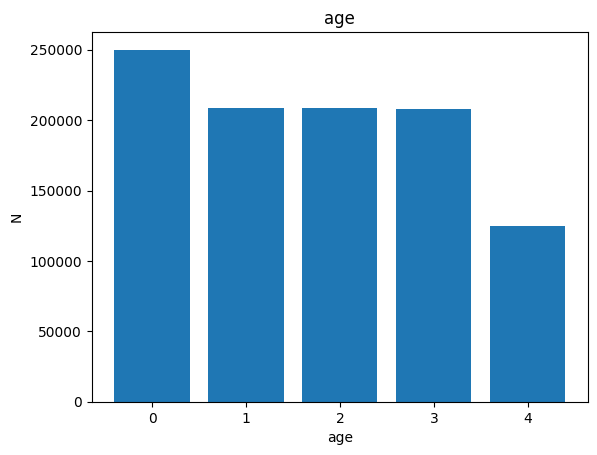

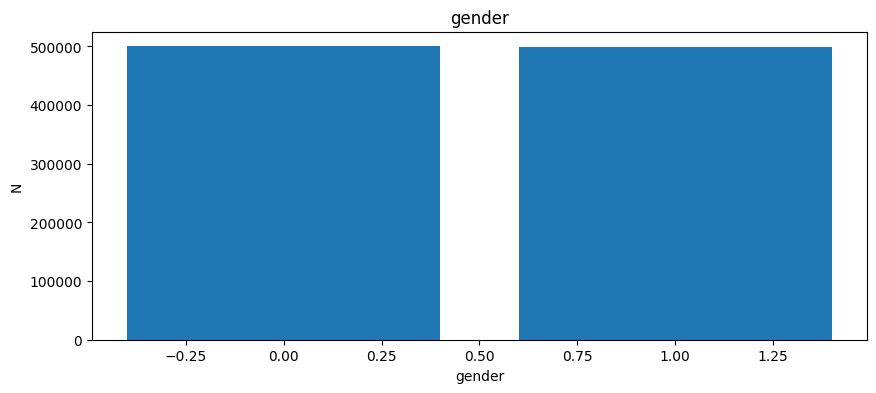

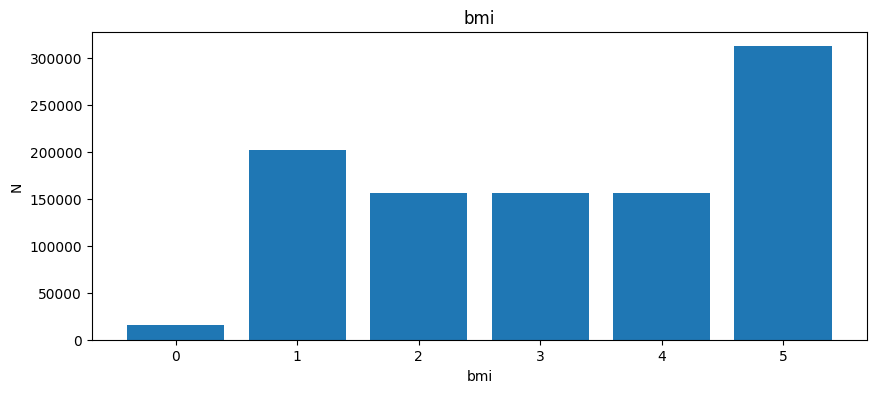

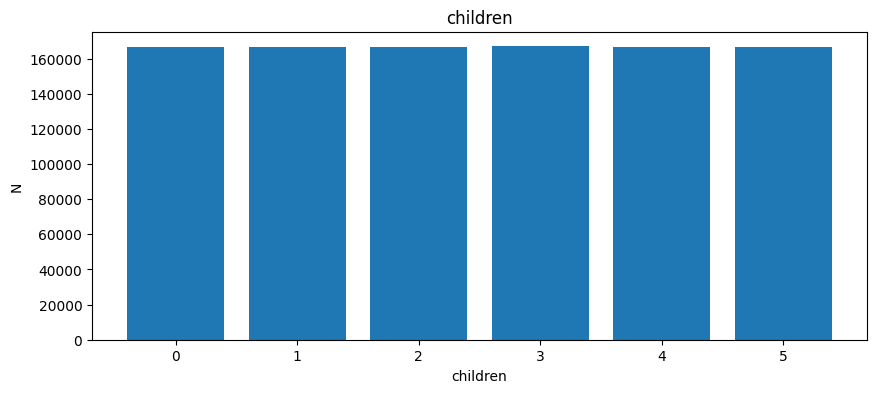

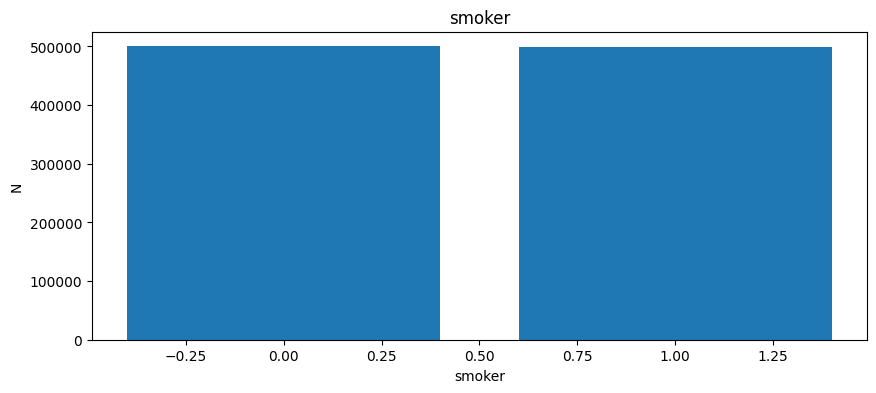

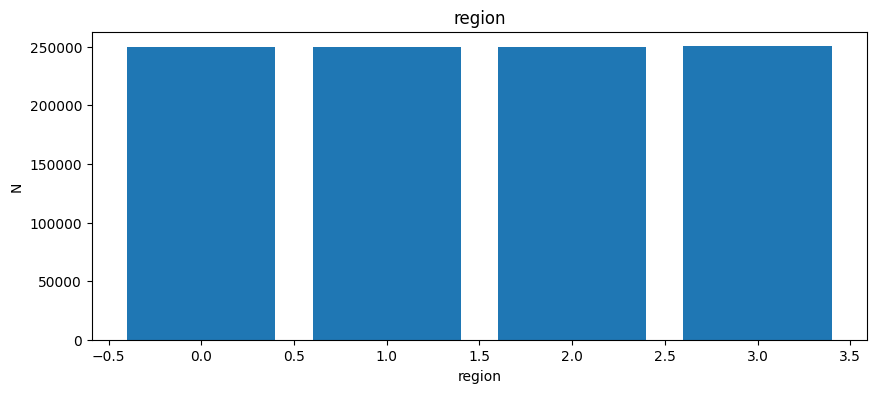

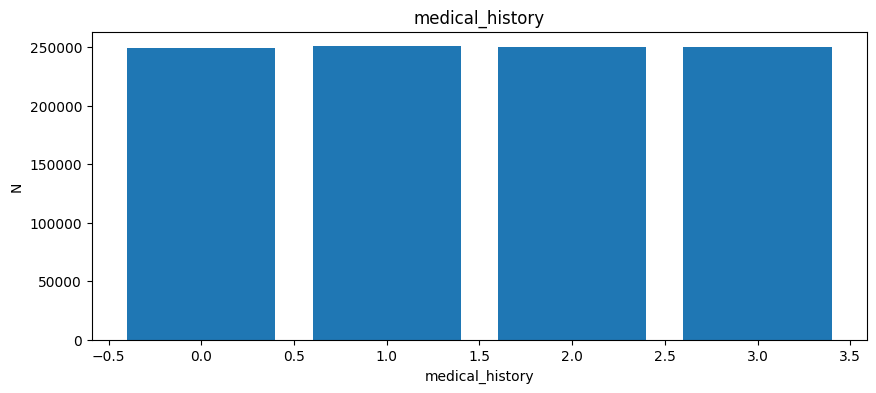

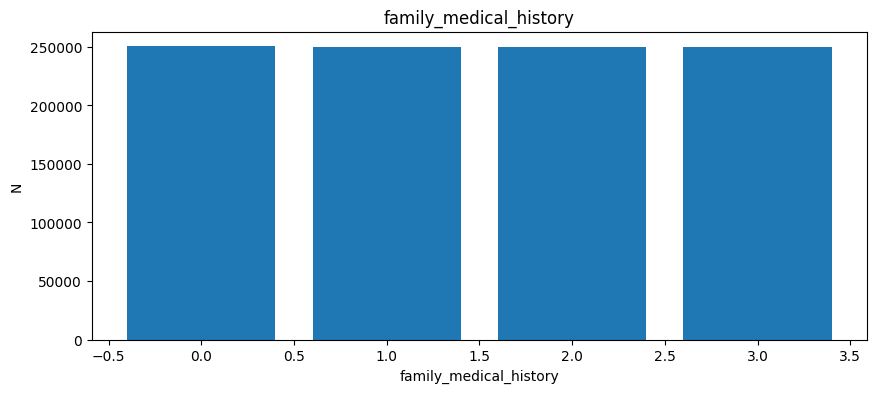

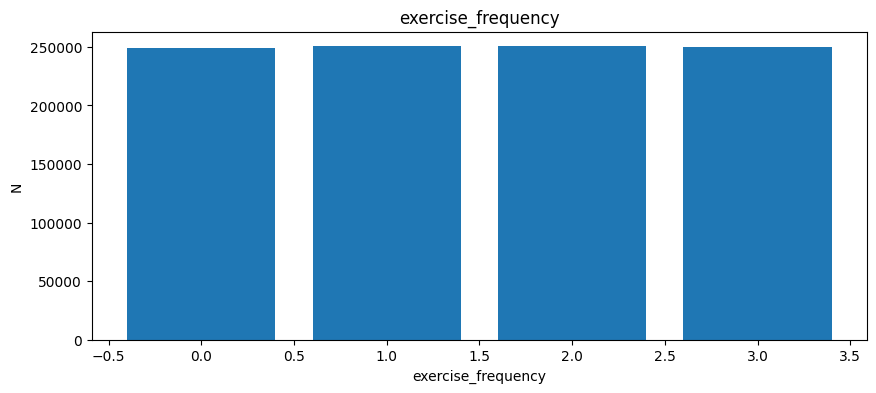

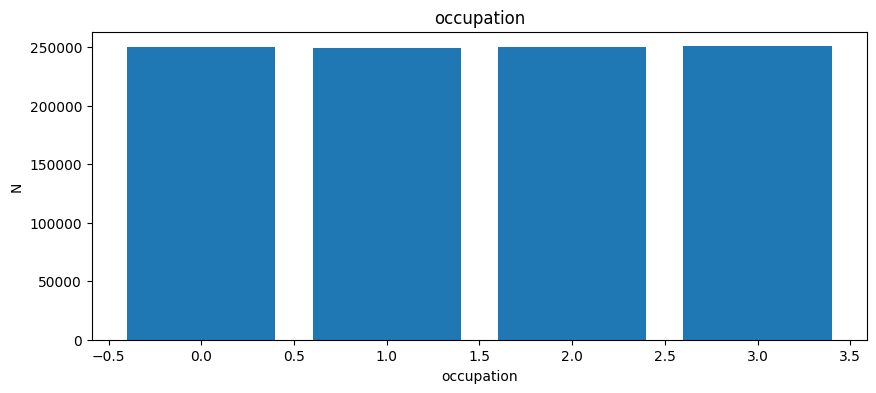

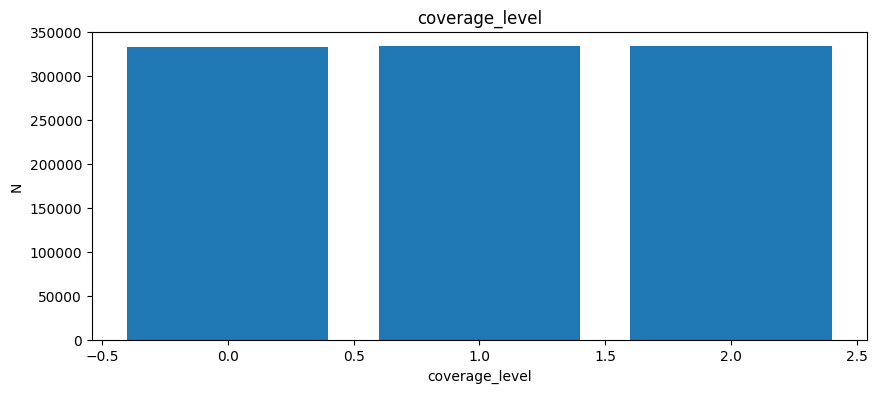

<Figure size 1000x400 with 0 Axes>

In [25]:
# Plot value counts for each column in X
for i in range(len(X.columns)):
  aggr = X[X.columns[i]].value_counts()

  plt.bar(aggr.index, aggr)
  plt.xlabel(X.columns[i])
  plt.ylabel("N")
  plt.title(X.columns[i])

  plt.figure(figsize=(10, 4))

In [26]:
# Get summary of the features
X, X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   age                     1000000 non-null  int8 
 1   gender                  1000000 non-null  int8 
 2   bmi                     1000000 non-null  int8 
 3   children                1000000 non-null  int8 
 4   smoker                  1000000 non-null  int8 
 5   region                  1000000 non-null  int8 
 6   medical_history         1000000 non-null  int8 
 7   family_medical_history  1000000 non-null  int8 
 8   exercise_frequency      1000000 non-null  int8 
 9   occupation              1000000 non-null  int8 
 10  coverage_level          1000000 non-null  int8 
dtypes: int8(11)
memory usage: 10.5 MB


(        age  gender  bmi  children  smoker  region  medical_history  \
 0         2       0    1         5       0       0                0   
 1         0       1    2         2       0       1                0   
 2         1       0    5         2       0       2                1   
 3         0       0    1         0       1       1                1   
 4         2       0    4         3       0       1                0   
 ...     ...     ...  ...       ...     ...     ...              ...   
 999995    3       0    5         2       1       3                2   
 999996    1       0    4         2       1       3                1   
 999997    1       0    4         0       0       3                3   
 999998    1       1    5         4       0       3                2   
 999999    2       0    3         2       0       3                0   
 
         family_medical_history  exercise_frequency  occupation  coverage_level  
 0                            0                   0 

In [27]:
# Split the dataset into train and test sets

X_train = X.sample(frac = 0.8, random_state = 42)
y_train = y.loc[X_train.index]

X_test = X.drop(X_train.index)
y_test = y.loc[X_test.index]


In [28]:
X_train, y_train

(        age  gender  bmi  children  smoker  region  medical_history  \
 987231    1       0    1         0       1       0                2   
 79954     1       0    2         1       0       3                3   
 567130    1       1    1         1       1       2                0   
 500891    0       0    1         0       1       0                0   
 55399     1       1    5         1       1       1                0   
 ...     ...     ...  ...       ...     ...     ...              ...   
 951873    2       1    5         2       0       1                0   
 350388    0       1    2         0       0       2                2   
 628199    2       0    1         3       1       0                1   
 168290    3       0    5         1       1       3                0   
 104460    1       1    3         4       0       0                1   
 
         family_medical_history  exercise_frequency  occupation  coverage_level  
 987231                       2                   3 

In [29]:
# Check the number of samples in training and test sets for features and target
len(X_train), len(y_train), len(X_test), len(y_test)

(800000, 800000, 200000, 200000)

## Create a model

In [30]:
# Configure gradient boosting model
gb = GradientBoosting(learners_count=200, learning_rate=0.01, max_depth=5, min_samples=10, splitting_threshold = 0.1)

# Fit the training data into the model
gb.fit(X_train, y_train)

Training Learner:  1
Training Learner:  2
Training Learner:  3
Training Learner:  4
Training Learner:  5
Training Learner:  6
Training Learner:  7
Training Learner:  8
Training Learner:  9
Training Learner:  10
Training Learner:  11
Training Learner:  12
Training Learner:  13
Training Learner:  14
Training Learner:  15
Training Learner:  16
Training Learner:  17
Training Learner:  18
Training Learner:  19
Training Learner:  20
Training Learner:  21
Training Learner:  22
Training Learner:  23
Training Learner:  24
Training Learner:  25
Training Learner:  26
Training Learner:  27
Training Learner:  28
Training Learner:  29
Training Learner:  30
Training Learner:  31
Training Learner:  32
Training Learner:  33
Training Learner:  34
Training Learner:  35
Training Learner:  36
Training Learner:  37
Training Learner:  38
Training Learner:  39
Training Learner:  40
Training Learner:  41
Training Learner:  42
Training Learner:  43
Training Learner:  44
Training Learner:  45
Training Learner:  

In [31]:
# Visualize learners
for i, tree in enumerate(gb.learners):

  print("Tree ", i + 1)

  tree.visualize()

Streaming output truncated to the last 5000 lines.
         -- 2 --> -356.03278060365494
         -- 1 --> -548.4656593552297
         -- 3 --> 173.58834414248625
         -- 0 --> -720.6156064245349
     -- 2 --> [ children ]
       -- 0 --> [ exercise_frequency ]
         -- 3 --> -211.20258184798215
         -- 0 --> -1108.1113168938264
         -- 2 --> -849.7918756230616
         -- 1 --> -626.8415096555207
       -- 1 --> [ coverage_level ]
         -- 1 --> -511.514749811147
         -- 0 --> -71.58153690427301
         -- 2 --> -913.1801517293554
       -- 4 --> [ exercise_frequency ]
         -- 3 --> 592.8905168984934
         -- 0 --> -379.41571683606276
         -- 2 --> -84.72876543432317
         -- 1 --> 170.33376829024274
       -- 5 --> [ family_medical_history ]
         -- 2 --> 271.07659376963664
         -- 1 --> 110.2270463042194
         -- 3 --> 829.6916868677067
         -- 0 --> -51.173213253465256
       -- 3 --> [ exercise_frequency ]
         -- 3 --> 389.1

## Evaluation

### Validation Loss

In [32]:
evaluate(gb, X_test, y_test)

{'mae': np.float64(870.0758639577576),
 'mse': np.float64(1178591.5509020232),
 'r2_score': np.float64(0.9393892608274781)}

### Training Loss

In [33]:
evaluate(gb, X_train, y_train)

{'mae': np.float64(871.4600506264851),
 'mse': np.float64(1182018.3792553542),
 'r2_score': np.float64(0.9394236305706082)}

<!-- Experimenting with hyperparameters -->

In [34]:
# # Helper function

# def experiment(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, configs: list, show_training_loss: bool = False):
#   """
#   Train and evaluate Gradient Boosting models for multiple configurations.

#   Parameters
#   ----------
#   X_train : pd.DataFrame
#       Training features.
#   y_train : pd.Series
#       Training labels.
#   X_test : pd.DataFrame
#       Validation/testing features.
#   y_test : pd.Series
#       Validation/testing labels.
#   configs : list
#       List of dictionaries with model parameters.
#   show_training_loss : bool, optional
#       If True, also compute training loss (default is False).

#   Returns
#   -------
#   list
#       List of config dictionaries updated with trained model and evaluation results.
#   """

#   configs_ = copy.deepcopy(configs)

#   for i, config in enumerate(configs_):
#     print("Training the model: ", i+1)
#     print("Config: ", config)

#     # Initialize model with config
#     gb_model = GradientBoosting(**config)

#     # Train model
#     gb_model.fit(X_train, y_train)

#     # Save trained model
#     config["model"] = gb_model

#     config["evaluation"] = {}

#     config["evaluation"]["validation_loss"] = evaluate(gb_model, X_test, y_test)

#     # Evaluate model
#     if show_training_loss:

#       config["evaluation"]["training_loss"] = evaluate(gb_model, X_train, y_train)

#     print(config["evaluation"])

#   return configs_

In [35]:
# # Set hyperparameter configurations to experiment on the model
# hyperparameter_configs = [
#   {
#     "learners_count": 100,
#     "learning_rate": 0.01,
#     "max_depth": 4,
#     "min_samples": 15,
#     "splitting_threshold": 0.15
#   },
#   {
#     "learners_count": 200,
#     "learning_rate": 0.01,
#     "max_depth": 4,
#     "min_samples": 10,
#     "splitting_threshold": 0.1
#   }
# ]

In [36]:
# # Get the result from the experiment
# result = experiment(X_train, y_train, X_test, y_test, hyperparameter_configs, show_training_loss = True)

In [37]:
# # Print the result of the experiment
# result

## Saving/Loading the models

### Save the model and the encoders

In [38]:
import pickle

# Save the trained model to a file
with open("gb_regression.pkl", "wb") as f:
  pickle.dump(gb, f)

# Save the encoders (e.g., for categorical features) to a file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

### Load the model and the encoders

In [39]:
import pickle

loaded_gb = None
loaded_encoder = None

# Load the trained model from file
with open("gb_regression.pkl", "rb") as f:
  loaded_gb = pickle.load(f)

# Load the encoders from file
with open("encoders.pkl", "rb") as f:
  loaded_encoder = pickle.load(f)

#### Evaulate the loaded model again on the test dataset

In [40]:
evaluate(loaded_gb, X_test, y_test)

{'mae': np.float64(870.0758639577576),
 'mse': np.float64(1178591.5509020232),
 'r2_score': np.float64(0.9393892608274781)}

#### Predict with the loaded model on a new unseen data

##### Apply the loaded encoders

In [41]:
# User's input data
input_data = {
  "age": 22,
  "gender": "male",
  "region": "southeast",
  "smoker": "yes",
  "children": 2,
  "occupation": "Unemployed",
  "bmi": 32,
  "medical_history": "no",
  "family_medical_history": "no",
  "exercise_frequency": "Never",
  "coverage_level": "Basic"
}

# Apply transformation
transfomed_input_data = loaded_encoder.transform(input_data)

##### Predict with the loaded model

In [42]:
predicted_charge = loaded_gb.predict(transfomed_input_data)
predicted_charge

np.float64(12695.276029057934)